# Label Clips - Testing Notebook

This notebook is a modular version of `label_clips.py` for easy testing and modification.

The notebook is organized into sections:
1. Imports
2. Configuration
3. Helper Functions (each in separate cells for easy modification)
4. Main Processing Function
5. Test Cells


## Imports


In [1]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.framework.formats import landmark_pb2
from mediapipe import solutions
import numpy as np
import imageio
import os
import json
import cv2


## Configuration


In [2]:
# Model path - change if using a different model
MODEL_PATH = 'hand_landmarker.task'

# Input folder - change to test on different data
INPUT_FOLDER = './data'

print(f"Using model from {MODEL_PATH}")
print(f"Input folder: {INPUT_FOLDER}")


Using model from hand_landmarker.task
Input folder: ./data


## Helper Functions


### Convert landmarks to list format


In [ ]:
def landmarks_to_list(landmarks):
    """Convert MediaPipe landmarks to a list of dictionaries."""
    return [{'x': lm.x, 'y': lm.y, 'z': lm.z} for lm in landmarks]


### Draw depth skeleton with colormap


In [70]:
def draw_depth_skeleton(height, width, hand_landmarks_list):
    """
    Draws a depth map with a continuous RGB colormap (Viridis):
    - Background is Black (0,0,0)
    - Close objects (low Z) are 'Hot'/Bright colors (e.g., Yellow in Viridis)
    - Far objects (high Z) are 'Cold'/Dark colors (e.g., Purple in Viridis)
    """
    depth_image = np.zeros((height, width, 3), dtype=np.uint8)

    if not hand_landmarks_list:
        return depth_image

    # 1. Generate the Colormap Lookup Table (LUT) once
    # We create a 1x256 image representing the gradient and apply the colormap
    # You can change cv2.COLORMAP_VIRIDIS to COLORMAP_JET, COLORMAP_PLASMA, etc.
    colormap_lut = cv2.applyColorMap(np.arange(256, dtype=np.uint8).reshape(1, 256), cv2.COLORMAP_VIRIDIS)

    # 2. Find global Min/Max Z to normalize
    all_z = [lm.z for hand in hand_landmarks_list for lm in hand]
    if not all_z: 
        return depth_image
        
    min_z, max_z = min(all_z), max(all_z)
    range_z = max_z - min_z if max_z != min_z else 1.0

    def get_color(z_val):
        """Map Z value to BGR Color from LUT. Closer (Lower Z) = Higher Index (Brighter/Yellow)."""
        # Normalize 0 to 1
        norm = (z_val - min_z) / range_z
        
        # Invert so Close (Low Z) maps to index 255 (Yellow in Viridis)
        # and Far (High Z) maps to index 0 (Purple in Viridis)
        color_index = int((1 - norm) * 255)
        
        # Clamp index just in case
        color_index = max(0, min(255, color_index))
        
        # Grab color from LUT (returns a numpy array [B, G, R])
        b, g, r = colormap_lut[0, color_index]
        return (int(b), int(g), int(r))

    # 3. Draw Bones (Lines)
    for landmarks in hand_landmarks_list:
        px_points = [
            (int(lm.x * width), int(lm.y * height)) 
            for lm in landmarks
        ]

        for connection in solutions.hands.HAND_CONNECTIONS:
            idx1, idx2 = connection
            
            # Average depth for the bone to determine color
            z1 = landmarks[idx1].z
            z2 = landmarks[idx2].z
            avg_z = (z1 + z2) / 2.0
            
            color = get_color(avg_z)
            
            start_point = px_points[idx1]
            end_point = px_points[idx2]

            cv2.line(depth_image, start_point, end_point, color, 2)

    # 4. Draw Joints (Circles)
    for landmarks in hand_landmarks_list:
        for i, lm in enumerate(landmarks):
            cx, cy = int(lm.x * width), int(lm.y * height)
            color = get_color(lm.z)
            cv2.circle(depth_image, (cx, cy), 3, color, -1)

    return depth_image


### Draw skeleton mask (white on black)


In [82]:
def draw_skeleton_mask(height, width, hand_landmarks_list):
    """Draws colored skeletons on a black background with custom finger colors."""
    mask_image = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Finger colors (RGB format)
    FINGER_COLORS = {
        'pinky': [[100, 0, 100], [150, 0, 150], [200, 0, 200], [255, 0, 255]],    # magenta gradient
        'ring': [[0, 50, 100], [0, 75, 150], [0, 100, 200], [0, 125, 255]],       # blue gradient  
        'middle': [[0, 100, 50], [0, 150, 75], [0, 200, 100], [0, 255, 125]],     # green gradient
        'index': [[100, 100, 0], [150, 150, 0], [200, 200, 0], [255, 255, 0]],    # yellow gradient
        'thumb': [[100, 0, 0], [150, 0, 0], [200, 0, 0], [255, 0, 0]]                          # red gradient
    }
    
    # Landmark color (pure blue in RGB)
    JOINT_RADIUS = 8
    LINE_THICKNESS = 5
    LANDMARK_COLOR = (100, 100, 100)  # Pure blue in RGB (BGR: (255, 0, 0))

    CONNECTIONS = {
        'thumb': [(0, 1), (1, 2), (2, 3), (3, 4)],
        'index': [(0, 5), (5, 6), (6, 7), (7, 8)],
        'middle': [(0, 9), (9, 10), (10, 11), (11, 12)],
        'ring': [(0, 13), (13, 14), (14, 15), (15, 16)],
        'pinky': [(0, 17), (17, 18), (18, 19), (19, 20)]
    }
    
    for landmarks in hand_landmarks_list:
        # Convert landmarks to pixel coordinates
        px_points = [
            (int(lm.x * width), int(lm.y * height)) 
            for lm in landmarks
        ]
        
        # Draw connections with finger-specific colors
        for finger, finger_connections in CONNECTIONS.items():
            for joint, (idx1, idx2) in enumerate(finger_connections):
                color_rgb = FINGER_COLORS[finger][joint]
                color = tuple(color_rgb)  # Use RGB directly
            
                start_point = px_points[idx1]
                end_point = px_points[idx2]
                cv2.line(mask_image, start_point, end_point, color, LINE_THICKNESS)
        
        # Draw landmarks as pure blue circles
        for i, lm in enumerate(landmarks):
            cx, cy = int(lm.x * width), int(lm.y * height)
            cv2.circle(mask_image, (cx, cy), JOINT_RADIUS, LANDMARK_COLOR, -1)
    
    return mask_image


### Draw RGB annotated (overlay on original image)


In [85]:
def draw_rgb_annotated(rgb_image, hand_landmarks_list):
    """Draws hand landmarks with custom finger colors on the original image."""
    annotated_image = np.copy(rgb_image)
    # Finger colors (RGB format)
    FINGER_COLORS = {
        'pinky': [[100, 0, 100], [150, 0, 150], [200, 0, 200], [255, 0, 255]],    # magenta gradient
        'ring': [[0, 50, 100], [0, 75, 150], [0, 100, 200], [0, 125, 255]],       # blue gradient  
        'middle': [[0, 100, 50], [0, 150, 75], [0, 200, 100], [0, 255, 125]],     # green gradient
        'index': [[100, 100, 0], [150, 150, 0], [200, 200, 0], [255, 255, 0]],    # yellow gradient
        'thumb': [[100, 0, 0], [150, 0, 0], [200, 0, 0], [255, 0, 0]]                          # red gradient
    }
    
    # Landmark color (pure blue in RGB)
    JOINT_RADIUS = 8
    LINE_THICKNESS = 5
    LANDMARK_COLOR = (100, 100, 100)  # Pure blue in RGB (BGR: (255, 0, 0))

    CONNECTIONS = {
        'thumb': [(0, 1), (1, 2), (2, 3), (3, 4)],
        'index': [(0, 5), (5, 6), (6, 7), (7, 8)],
        'middle': [(0, 9), (9, 10), (10, 11), (11, 12)],
        'ring': [(0, 13), (13, 14), (14, 15), (15, 16)],
        'pinky': [(0, 17), (17, 18), (18, 19), (19, 20)]
    }
    
    h, w = rgb_image.shape[:2]
    
    for landmarks in hand_landmarks_list:
        # Convert landmarks to pixel coordinates
        px_points = [
            (int(lm.x * w), int(lm.y * h)) 
            for lm in landmarks
        ]
        
        # Draw connections with finger-specific colors
        for finger, finger_connections in CONNECTIONS.items():
            for joint, (idx1, idx2) in enumerate(finger_connections):
                color_rgb = FINGER_COLORS[finger][joint]
                color = tuple(color_rgb)  # Use RGB directly
            
                start_point = px_points[idx1]
                end_point = px_points[idx2]
                cv2.line(annotated_image, start_point, end_point, color, LINE_THICKNESS)
        
        # Draw landmarks as pure blue circles
        for i, lm in enumerate(landmarks):
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated_image, (cx, cy), JOINT_RADIUS, LANDMARK_COLOR, -1)
    
    return annotated_image


## Main Processing Function


In [92]:
def process_video(video_path, output_root, model_path=MODEL_PATH):
    """
    Process a single video file and generate annotated outputs.
    
    Args:
        video_path: Path to input video file
        output_root: Root directory for output (will create video_id/start_frame/ structure)
        model_path: Path to MediaPipe hand landmarker model
    """
    # Construct Output Paths
    # Structure: output_root/video_id/start_frame/
    parts = video_path.split(os.sep)
    video_id = parts[-3]
    start_frame = parts[-2]
    
    # Create specific output dir
    save_dir = os.path.join(output_root, video_id, start_frame)
    os.makedirs(save_dir, exist_ok=True)
    
    path_rgb = os.path.join(save_dir, "annotated_rgb.mp4")
    path_mask = os.path.join(save_dir, "skeleton_mask.mp4")
    path_depth = os.path.join(save_dir, "depth_map.mp4")
    path_json = os.path.join(save_dir, "landmarks.json")

    print(f"Processing: {video_id}/{start_frame}")

    # Initialize MediaPipe
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
        running_mode=mp.tasks.vision.RunningMode.VIDEO, 
        num_hands=10,  # Detect up to 10 hands (effectively all visible hands)
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
    )

    try:
        reader = imageio.get_reader(video_path)
        meta = reader.get_meta_data()
        fps = meta['fps']
        size = meta['size'] # (width, height)
        w, h = size
        
        writer_rgb = imageio.get_writer(path_rgb, fps=fps, codec='libx264', macro_block_size=1)
        writer_mask = imageio.get_writer(path_mask, fps=fps, codec='libx264', macro_block_size=1)
        writer_depth = imageio.get_writer(path_depth, fps=fps, codec='libx264', macro_block_size=1)
        
        results_dict = {}

        success = True
        failed_frame = None
        with mp.tasks.vision.HandLandmarker.create_from_options(options) as landmarker:
            for i, frame in enumerate(reader):
                # MP requires RGB
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
                timestamp_ms = int((i * 1000) / fps)
                
                # Detect
                detection_result = landmarker.detect_for_video(mp_image, timestamp_ms)

                # Extract Landmarks (Standard Detection, No Force Swap)
                current_hands_lms = detection_result.hand_landmarks

                # 1. Create Annotated RGB
                frame_rgb_out = draw_rgb_annotated(frame, current_hands_lms)
                
                # 2. Create Skeleton Mask (Black BG)
                frame_mask_out = draw_skeleton_mask(h, w, current_hands_lms)
                
                # 3. Create Depth Map (Grayscale Interp)
                frame_depth_out = draw_depth_skeleton(h, w, current_hands_lms)

                if len(detection_result.hand_landmarks) > 2:
                    success = False
                    print(f"Failed frame {i} with {len(detection_result.hand_landmarks)} hands detected")
                    failed_frame = frame_rgb_out
                
                
                # Write Frames
                writer_rgb.append_data(frame_rgb_out)
                writer_mask.append_data(frame_mask_out)
                writer_depth.append_data(frame_depth_out)
                
                # Store JSON Data
                if current_hands_lms:
                    frame_data = []
                    for idx, hand_lms in enumerate(current_hands_lms):
                        # Get label if available
                        label = "Unknown"
                        if idx < len(detection_result.handedness):
                             label = detection_result.handedness[idx][0].category_name
                        
                        frame_data.append({
                            "label": label,
                            "landmarks": landmarks_to_list(hand_lms)
                        })
                    results_dict[i] = frame_data

        reader.close()
        writer_rgb.close()
        writer_mask.close()
        writer_depth.close()
        
        with open(path_json, 'w') as f:
            json.dump(results_dict, f, indent=4)
            
    except Exception as e:
        print(f"Error processing {video_id}/{start_frame}: {e}")
    return success, failed_frame


### Test: Process a single video

Modify the paths below to test on a specific video.


In [95]:
# Test on a single video
# Modify these paths to test different videos
test_video_id = 'ecdc21d9-ee59-48ab-ae02-53e9aba05ef8'
test_start_frame = '7211'
# test_start_frame = '15602'
test_video_path = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame, 'video.mp4')

if os.path.exists(test_video_path):
    print(f"Testing on: {test_video_path}")
    success, failed_frame = process_video(test_video_path, INPUT_FOLDER)
    if success:
        print("Successfully processed video")
    else:
        print("Failed to process video")
        # Save the failed frame as an image
        if failed_frame is not None:
            save_dir = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame)
            os.makedirs(save_dir, exist_ok=True)
            failed_frame_path = os.path.join(save_dir, "failed_frame.png")
            # Convert RGB to BGR for cv2.imwrite (OpenCV uses BGR)
            failed_frame_bgr = cv2.cvtColor(failed_frame, cv2.COLOR_RGB2BGR)
            cv2.imwrite(failed_frame_path, failed_frame_bgr)
            print(f"Saved failed frame to: {failed_frame_path}")
        else:
            print("No failed frame captured")

else:
    print(f"Video not found: {test_video_path}")
    print("Available video IDs:")
    if os.path.exists(INPUT_FOLDER):
        for vid_id in sorted(os.listdir(INPUT_FOLDER))[:5]:  # Show first 5
            vid_path = os.path.join(INPUT_FOLDER, vid_id)
            if os.path.isdir(vid_path):
                print(f"  {vid_id}")


Testing on: ./data\ecdc21d9-ee59-48ab-ae02-53e9aba05ef8\7211\video.mp4
Processing: ecdc21d9-ee59-48ab-ae02-53e9aba05ef8/7211
Successfully processed video


### Test: Process all videos (full pipeline)

This replicates the main script's behavior - processes all videos in the input folder.


In [ ]:
# Process all videos in the input folder
input_folder = INPUT_FOLDER

if not os.path.exists(input_folder):
    print(f"Error: Input folder '{input_folder}' does not exist.")
else:
    for video_id in os.listdir(input_folder):
        video_id_path = os.path.join(input_folder, video_id)
        if not os.path.isdir(video_id_path): 
            continue

        start_frames = os.listdir(video_id_path)
        start_frames.sort(key=lambda x: int(x))
        for start_frame in start_frames:
            print(f"Processing {video_id}/{start_frame}")
            start_frame_path = os.path.join(video_id_path, start_frame)
            if not os.path.isdir(start_frame_path): 
                continue
            
            video_path = os.path.join(start_frame_path, 'video.mp4')
            
            if os.path.exists(video_path):
                process_video(video_path, input_folder)
            else:
                print(f"Skipping {start_frame_path}, no video.mp4 found.")


### Test: Inspect a single frame

Use this cell to test drawing functions on a single frame for debugging.


Original frame shape: (1440, 1920, 3)
Square frame shape: (1440, 1440, 3)
1
All attributes of detection_result:

hand_landmarks:
  Type: <class 'list'>
  Value: [[NormalizedLandmark(x=1.0024006366729736, y=0.43341144919395447, z=-1.1877489214384696e-07, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.9750992655754089, y=0.4254473149776459, z=-0.046262238174676895, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.9338926076889038, y=0.3978528082370758, z=-0.05486305430531502, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8940314054489136, y=0.37360137701034546, z=-0.05443674325942993, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8659171462059021, y=0.3510850667953491, z=-0.05209466442465782, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.9336163997650146, y=0.3380843698978424, z=-0.01097431592643261, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.8816792368888855, y=0.32648444175720215, z=-0.016333673149347305, visibility=0.0, presence=0.0), Nor

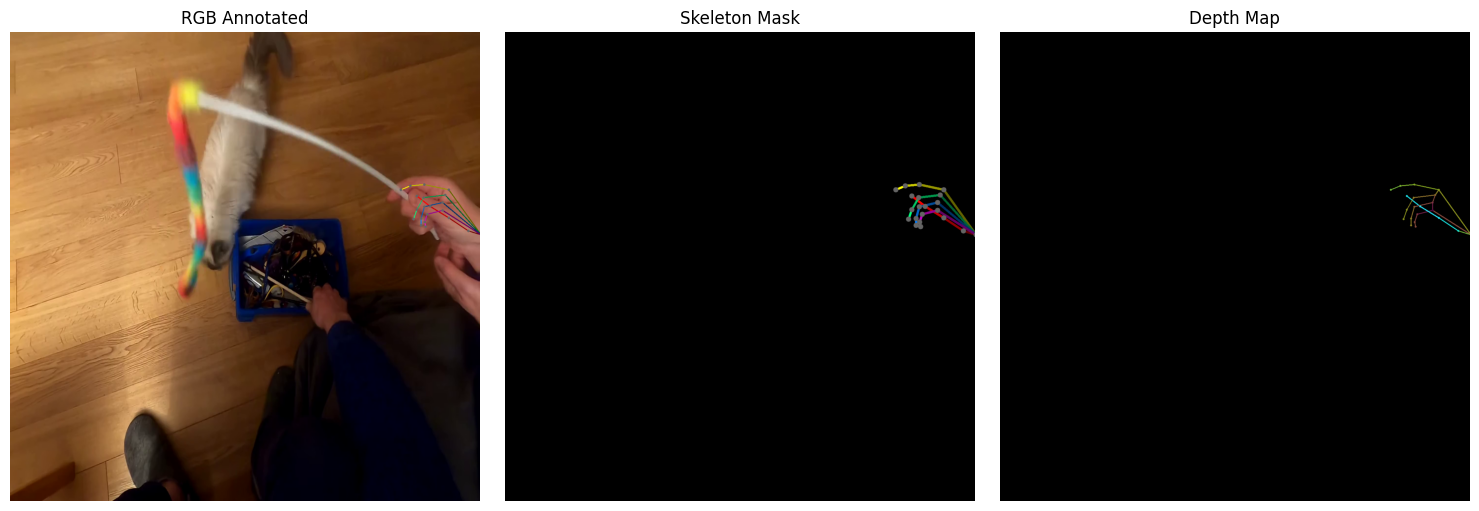

Number of hands detected: 1


In [83]:
# Test drawing functions on a single frame
from IPython.display import display, Image
import matplotlib.pyplot as plt

# Load a test video frame
test_video_id = '000cd456-ff8d-499b-b0c1-4acead128a8b'
test_start_frame = '1083'
test_video_path = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame, 'video.mp4')

if os.path.exists(test_video_path):
    reader = imageio.get_reader(test_video_path)
    frame = reader.get_data(0)  # Get first frame
    reader.close()
    
    # Make frame square by resizing with OpenCV
    h, w = frame.shape[:2]
    print(f"Original frame shape: {frame.shape}")
    
    # Resize to square (use larger dimension to avoid losing information)
    square_size = min(h, w)
    frame = cv2.resize(frame, (square_size, square_size), interpolation=cv2.INTER_LINEAR)
    
    h, w = frame.shape[:2]
    print(f"Square frame shape: {frame.shape}")
    
    # Initialize MediaPipe for single frame
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_hands=10,  # Detect up to 10 hands (effectively all visible hands)
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
    )
    
    # Detect hands
    with mp.tasks.vision.HandLandmarker.create_from_options(options) as landmarker:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        detection_result = landmarker.detect(mp_image)

        print(len(detection_result.hand_landmarks))
        
        # Print all attributes of detection_result
        print("=" * 60)
        print("All attributes of detection_result:")
        print("=" * 60)
        for attr in dir(detection_result):
            if not attr.startswith('_'):  # Skip private/magic methods
                try:
                    value = getattr(detection_result, attr)
                    if not callable(value):  # Only print non-callable attributes
                        print(f"\n{attr}:")
                        print(f"  Type: {type(value)}")
                        print(f"  Value: {value}")
                except Exception as e:
                    print(f"\n{attr}: (Error accessing: {e})")
        print("=" * 60)
        
        current_hands_lms = detection_result.hand_landmarks
    
    # Test drawing functions
    frame_rgb = draw_rgb_annotated(frame, current_hands_lms)
    frame_mask = draw_skeleton_mask(h, w, current_hands_lms)
    frame_depth = draw_depth_skeleton(h, w, current_hands_lms)
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(frame_rgb)
    axes[0].set_title('RGB Annotated')
    axes[0].axis('off')
    
    axes[1].imshow(frame_mask)
    axes[1].set_title('Skeleton Mask')
    axes[1].axis('off')
    
    axes[2].imshow(frame_depth)
    axes[2].set_title('Depth Map')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Number of hands detected: {len(current_hands_lms)}")
else:
    print(f"Video not found: {test_video_path}")


### Test: Verify fused_pose.npy and intri.npy contents

This cell reads and prints metadata for fused_pose.npy and intri.npy from a single data file.


In [3]:
# Test reading fused_pose.npy and intri.npy from a single data file
test_video_id = '000cd456-ff8d-499b-b0c1-4acead128a8b'
test_start_frame = '1083'

# Construct paths
data_dir = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame)
fused_pose_path = os.path.join(data_dir, 'fused_pose.npy')
intri_path = os.path.join(data_dir, 'intri.npy')

print(f"Reading data from: {data_dir}")
print("=" * 60)

# Load and inspect fused_pose.npy
if os.path.exists(fused_pose_path):
    print("\n[fused_pose.npy]")
    print("-" * 60)
    fused_pose = np.load(fused_pose_path)
    print(f"Shape: {fused_pose.shape}")
    print(f"Dtype: {fused_pose.dtype}")
    print(f"Size: {fused_pose.size} elements")
    print(f"First elem: {fused_pose[0]}")
else:
    print(f"\n[fused_pose.npy] - File not found at: {fused_pose_path}")

# Load and inspect intri.npy
if os.path.exists(intri_path):
    print("\n[intri.npy]")
    print("-" * 60)
    intri = np.load(intri_path)
    print(f"Shape: {intri.shape}")
    print(f"elems: {intri}")
else:
    print(f"\n[intri.npy] - File not found at: {intri_path}")

print("\n" + "=" * 60)


Reading data from: ./data\000cd456-ff8d-499b-b0c1-4acead128a8b\1083

[fused_pose.npy]
------------------------------------------------------------
Shape: (120, 4, 4)
Dtype: float64
Size: 1920 elements
First elem: [[ 1.00000000e+00  4.39086911e-18  1.47427546e-17  0.00000000e+00]
 [-4.39086911e-18  1.00000000e+00  9.38044809e-18  0.00000000e+00]
 [-1.47427546e-17 -9.38044809e-18  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

[intri.npy]
------------------------------------------------------------
Shape: (3, 3)
elems: [[366.95001994   0.         360.        ]
 [  0.         366.95001994 272.        ]
 [  0.           0.           1.        ]]



### Plot Camera Trajectory from fused_pose.npy

This cell plots the 3D camera trajectory from fused_pose.npy with camera frustums.


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px

def plot_camera_trajectory(fused_pose_path, save_path=None):
    """
    Plot camera trajectory from fused_pose.npy file.
    
    Args:
        fused_pose_path: Path to fused_pose.npy file (shape: [N, 4, 4])
        save_path: Optional path to save the plot
    """
    # Load poses
    poses = np.load(fused_pose_path)  # Shape: [N, 4, 4]
    print(f"Loaded {len(poses)} camera poses from {fused_pose_path}")
    
    def set_axes_equal(ax):
        """Set 3D plot axes to equal scale"""
        limits = np.array([
            ax.get_xlim3d(),
            ax.get_ylim3d(),
            ax.get_zlim3d(),
        ])
        
        origin = np.mean(limits, axis=1)
        radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
        
        ax.set_xlim3d([origin[0] - radius, origin[0] + radius])
        ax.set_ylim3d([origin[1] - radius, origin[1] + radius])
        ax.set_zlim3d([origin[2] - radius, origin[2] + radius])
    
    def draw_camera_frustum(ax, c2w, color, alpha=0.3, scale=0.05):
        """Draw camera frustum as pyramid"""
        # Camera frustum vertices in camera space
        vertices = np.array([
            [0, 0, 0, 1],                          # apex (camera center)
            [scale, -scale*0.75, scale*2, 1],      # bottom right
            [scale, scale*0.75, scale*2, 1],       # top right
            [-scale, scale*0.75, scale*2, 1],      # top left
            [-scale, -scale*0.75, scale*2, 1]      # bottom left
        ])
        
        # Transform to world space
        vertices_world = (c2w @ vertices.T).T[:, :3]
        
        # Define pyramid faces
        faces = [
            [vertices_world[0], vertices_world[1], vertices_world[2]],  # apex to right edge
            [vertices_world[0], vertices_world[2], vertices_world[3]],  # apex to top edge
            [vertices_world[0], vertices_world[3], vertices_world[4]],  # apex to left edge
            [vertices_world[0], vertices_world[4], vertices_world[1]],  # apex to bottom edge
            [vertices_world[1], vertices_world[2], vertices_world[3], vertices_world[4]]  # base
        ]
        
        ax.add_collection3d(Poly3DCollection(
            faces, facecolors=color, linewidths=0.3, 
            edgecolors=color, alpha=alpha
        ))
    
    def draw_coordinate_axes(ax, c2w, scale=1.0, add_legend=False):
        """Draw coordinate axes at camera location"""
        origin = c2w[:3, 3]  # Camera center
        # Extract camera orientation
        x_axis = c2w[:3, 0] * scale
        y_axis = c2w[:3, 1] * scale
        z_axis = c2w[:3, 2] * scale
        
        ax.quiver(origin[0], origin[1], origin[2], x_axis[0], x_axis[1], x_axis[2], 
                color='r', arrow_length_ratio=0.3, linewidth=2, label='X' if add_legend else '')
        ax.quiver(origin[0], origin[1], origin[2], y_axis[0], y_axis[1], y_axis[2], 
                color='g', arrow_length_ratio=0.3, linewidth=2, label='Y' if add_legend else '')
        ax.quiver(origin[0], origin[1], origin[2], z_axis[0], z_axis[1], z_axis[2], 
                color='b', arrow_length_ratio=0.3, linewidth=2, label='Z' if add_legend else '')
    
    # Extract camera centers (translation from 4x4 matrices)
    camera_centers = np.array([pose[:3, 3] for pose in poses])
    
    # Calculate scale based on trajectory extent
    extent = np.max(camera_centers, axis=0) - np.min(camera_centers, axis=0)
    frustum_scale = np.max(extent) * 0.1 if np.max(extent) > 0 else 0.1
    
    print(f"Trajectory extent: {extent}")
    print(f"Camera center range:")
    print(f"  X: [{np.min(camera_centers[:, 0]):.3f}, {np.max(camera_centers[:, 0]):.3f}]")
    print(f"  Y: [{np.min(camera_centers[:, 1]):.3f}, {np.max(camera_centers[:, 1]):.3f}]")
    print(f"  Z: [{np.min(camera_centers[:, 2]):.3f}, {np.max(camera_centers[:, 2]):.3f}]")
    
    # Create plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot trajectory
    ax.plot(camera_centers[:, 0], camera_centers[:, 1], camera_centers[:, 2], 
            'b-', label='Camera Trajectory', linewidth=2, alpha=0.7)
    
    # Draw camera frustums (sample every N frames to avoid clutter)
    num_frustums = min(10, len(poses))
    step = max(1, len(poses) // num_frustums)
    
    # Store colors for legend - get first and last frame colors
    first_frame_color = plt.cm.Blues(0.5) if len(poses) > 1 else plt.cm.Blues(0.5)
    last_frame_color = plt.cm.Blues(1.0) if len(poses) > 1 else plt.cm.Blues(0.5)
    
    for i in range(0, len(poses), step):
        color_intensity = i / len(poses) if len(poses) > 1 else 0.5
        color = plt.cm.Blues(0.5 + color_intensity*0.5)
        draw_camera_frustum(ax, poses[i], color, 
                           alpha=0.4, scale=frustum_scale)
    
    # Draw coordinate axes at first and last camera
    if len(poses) > 0:
        draw_coordinate_axes(ax, poses[0], scale=frustum_scale*2, add_legend=True)
        if len(poses) > 1:
            draw_coordinate_axes(ax, poses[-1], scale=frustum_scale*2)
    
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('Z', fontsize=12)
    ax.set_title('Camera Trajectory from fused_pose.npy', fontsize=14, fontweight='bold')
    
    # Create custom legend entries for frame colors
    legend_elements = [
        plt.Line2D([0], [0], color='blue', linewidth=2, alpha=0.7, label='Camera Trajectory'),
    ]
    
    if first_frame_color is not None and last_frame_color is not None and len(poses) > 1:
        legend_elements.extend([
            Patch(facecolor=first_frame_color, edgecolor='black', alpha=0.6, label='First Frame (Lighter)'),
            Patch(facecolor=last_frame_color, edgecolor='black', alpha=0.6, label='Last Frame (Darker)'),
        ])
    elif first_frame_color is not None:
        legend_elements.append(
            Patch(facecolor=first_frame_color, edgecolor='black', alpha=0.6, label='Camera Frustum')
        )
    
    ax.legend(handles=legend_elements)
    set_axes_equal(ax)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved trajectory plot to {save_path}")
    
    plt.show()


### Interactive Plot Camera Trajectory (Plotly)

This cell provides an interactive version using Plotly for better 3D exploration.


In [5]:
def plot_camera_trajectory_interactive(fused_pose_path):
    """
    Plot interactive camera trajectory from fused_pose.npy file using Plotly.
    
    Args:
        fused_pose_path: Path to fused_pose.npy file (shape: [N, 4, 4])
    """
    # Load poses
    poses = np.load(fused_pose_path)  # Shape: [N, 4, 4]
    print(f"Loaded {len(poses)} camera poses from {fused_pose_path}")
    
    def get_camera_frustum_vertices(c2w, scale=0.05):
        """Get camera frustum vertices in world space"""
        # Camera frustum vertices in camera space
        vertices_cam = np.array([
            [0, 0, 0, 1],                          # apex (camera center)
            [scale, -scale*0.75, scale*2, 1],      # bottom right
            [scale, scale*0.75, scale*2, 1],       # top right
            [-scale, scale*0.75, scale*2, 1],      # top left
            [-scale, -scale*0.75, scale*2, 1]      # bottom left
        ])
        
        # Transform to world space
        vertices_world = (c2w @ vertices_cam.T).T[:, :3]
        return vertices_world
    
    def draw_frustum_wireframe(fig, vertices, color, name='', showlegend=False):
        """Draw frustum as wireframe using lines"""
        # Edges of the frustum pyramid
        edges = [
            [0, 1], [0, 2], [0, 3], [0, 4],  # from apex to corners
            [1, 2], [2, 3], [3, 4], [4, 1]   # base edges
        ]
        
        for edge in edges:
            fig.add_trace(go.Scatter3d(
                x=vertices[edge, 0],
                y=vertices[edge, 1],
                z=vertices[edge, 2],
                mode='lines',
                line=dict(color=color, width=2),
                showlegend=showlegend and edge == edges[0],
                name=name,
                legendgroup='frustums',
                hoverinfo='skip'
            ))
    
    # Extract camera centers (translation from 4x4 matrices)
    camera_centers = np.array([pose[:3, 3] for pose in poses])
    
    # Calculate scale based on trajectory extent
    extent = np.max(camera_centers, axis=0) - np.min(camera_centers, axis=0)
    frustum_scale = np.max(extent) * 0.1 if np.max(extent) > 0 else 0.1
    
    print(f"Trajectory extent: {extent}")
    print(f"Camera center range:")
    print(f"  X: [{np.min(camera_centers[:, 0]):.3f}, {np.max(camera_centers[:, 0]):.3f}]")
    print(f"  Y: [{np.min(camera_centers[:, 1]):.3f}, {np.max(camera_centers[:, 1]):.3f}]")
    print(f"  Z: [{np.min(camera_centers[:, 2]):.3f}, {np.max(camera_centers[:, 2]):.3f}]")
    
    # Create figure
    fig = go.Figure()
    
    # Plot trajectory line
    fig.add_trace(go.Scatter3d(
        x=camera_centers[:, 0],
        y=camera_centers[:, 1],
        z=camera_centers[:, 2],
        mode='lines',
        name='Camera Trajectory',
        line=dict(color='blue', width=4),
        showlegend=True
    ))
    
    # Draw camera frustums (sample every N frames to avoid clutter)
    num_frustums = min(10, len(poses))
    step = max(1, len(poses) // num_frustums)
    
    # Get colors for first and last frame
    first_frame_color = px.colors.sample_colorscale("Blues", [0.5])[0]
    last_frame_color = px.colors.sample_colorscale("Blues", [1.0])[0]
    
    frustum_indices = list(range(0, len(poses), step))
    if frustum_indices[-1] != len(poses) - 1:
        frustum_indices.append(len(poses) - 1)
    
    for idx, i in enumerate(frustum_indices):
        color_intensity = i / len(poses) if len(poses) > 1 else 0.5
        color = px.colors.sample_colorscale("Blues", [0.5 + color_intensity*0.5])[0]
        
        vertices = get_camera_frustum_vertices(poses[i], scale=frustum_scale)
        
        # Draw frustum as wireframe
        draw_frustum_wireframe(fig, vertices, color, 
                              name='Camera Frustums' if idx == 0 else '',
                              showlegend=(idx == 0))
    
    # Draw coordinate axes at first camera
    if len(poses) > 0:
        origin = poses[0][:3, 3]
        axes_scale = frustum_scale * 2
        
        # X axis (red)
        x_axis = poses[0][:3, 0] * axes_scale
        fig.add_trace(go.Scatter3d(
            x=[origin[0], origin[0] + x_axis[0]],
            y=[origin[1], origin[1] + x_axis[1]],
            z=[origin[2], origin[2] + x_axis[2]],
            mode='lines+markers',
            line=dict(color='red', width=4),
            marker=dict(size=3),
            name='X axis',
            showlegend=True
        ))
        
        # Y axis (green)
        y_axis = poses[0][:3, 1] * axes_scale
        fig.add_trace(go.Scatter3d(
            x=[origin[0], origin[0] + y_axis[0]],
            y=[origin[1], origin[1] + y_axis[1]],
            z=[origin[2], origin[2] + y_axis[2]],
            mode='lines+markers',
            line=dict(color='green', width=4),
            marker=dict(size=3),
            name='Y axis',
            showlegend=True
        ))
        
        # Z axis (blue)
        z_axis = poses[0][:3, 2] * axes_scale
        fig.add_trace(go.Scatter3d(
            x=[origin[0], origin[0] + z_axis[0]],
            y=[origin[1], origin[1] + z_axis[1]],
            z=[origin[2], origin[2] + z_axis[2]],
            mode='lines+markers',
            line=dict(color='blue', width=4),
            marker=dict(size=3),
            name='Z axis',
            showlegend=True
        ))
    
    # Add legend entries for frame colors
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(size=10, color=first_frame_color),
        name='First Frame (Lighter)',
        showlegend=True
    ))
    
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='markers',
        marker=dict(size=10, color=last_frame_color),
        name='Last Frame (Darker)',
        showlegend=True
    ))
    
    # Update layout
    fig.update_layout(
        title='Camera Trajectory from fused_pose.npy (Interactive)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data',  # Equal aspect ratio
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=1000,
        height=800,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    fig.show()


In [11]:
# Test interactive plotting
test_video_id = '000cd456-ff8d-499b-b0c1-4acead128a8b'
test_start_frame = '3172'

# Construct path
data_dir = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame)
fused_pose_path = os.path.join(data_dir, 'fused_pose.npy')

if os.path.exists(fused_pose_path):
    plot_camera_trajectory_interactive(fused_pose_path)
else:
    print(f"File not found: {fused_pose_path}")


Loaded 120 camera poses from ./data\000cd456-ff8d-499b-b0c1-4acead128a8b\3172\fused_pose.npy
Trajectory extent: [0.08848322 0.03756012 0.01450526]
Camera center range:
  X: [-0.088, 0.000]
  Y: [-0.012, 0.026]
  Z: [-0.013, 0.001]


Loaded 120 camera poses from ./data\000cd456-ff8d-499b-b0c1-4acead128a8b\24\fused_pose.npy
Trajectory extent: [0.14939574 0.12037858 0.23823316]
Camera center range:
  X: [-0.077, 0.073]
  Y: [-0.009, 0.111]
  Z: [-0.006, 0.232]


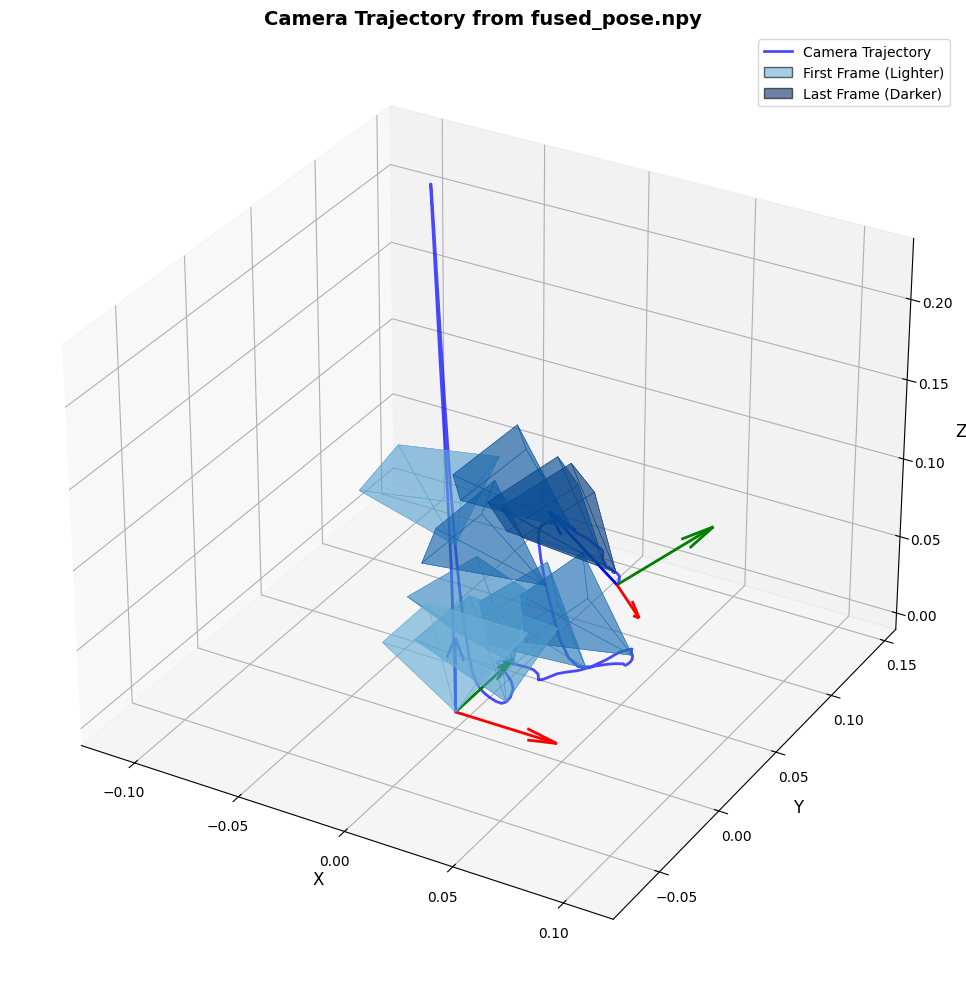

In [9]:
# Test plotting camera trajectory
# Construct path
test_video_id = '000cd456-ff8d-499b-b0c1-4acead128a8b'
test_start_frame = '24'
data_dir = os.path.join(INPUT_FOLDER, test_video_id, test_start_frame)
fused_pose_path = os.path.join(data_dir, 'fused_pose.npy')

if os.path.exists(fused_pose_path):
    plot_camera_trajectory(fused_pose_path)
else:
    print(f"File not found: {fused_pose_path}")
